In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/cleaned_transactions.csv")

In [2]:
df.head()
df.shape


(250000, 21)

In [3]:
#user behavior summary
user_profile = (
    df.groupby(
        [
            "sender_age_group",
            "sender_state",
            "sender_bank"
        ]
    )
    .agg(
        transaction_count=("transaction_id","count"),
        total_spend=("amount_inr","sum"),
        avg_spend=("amount_inr","mean"),
        fraud_count=("fraud_flag","sum")
    )
    .reset_index()
)

user_profile.head()


#Transaction Frequency Segmentation

q1 = user_profile["transaction_count"].quantile(0.25)
q2 = user_profile["transaction_count"].quantile(0.50)
q3 = user_profile["transaction_count"].quantile(0.75)



def frequency_segment(x):

    if x <= q1:
        return "Low Usage"

    elif x <= q2:
        return "Medium Usage"

    elif x <= q3:
        return "High Usage"

    else:
        return "Power User"
    



user_profile["usage_segment"] = (
    user_profile["transaction_count"]
    .apply(frequency_segment)
)

In [4]:
#Spending Segmentation

s1 = user_profile["total_spend"].quantile(0.25)
s2 = user_profile["total_spend"].quantile(0.50)
s3 = user_profile["total_spend"].quantile(0.75)

def spending_segment(x):

    if x <= s1:
        return "Low Value"

    elif x <= s2:
        return "Medium Value"

    elif x <= s3:
        return "High Value"

    else:
        return "Premium User"
    

user_profile["spending_segment"] = (
    user_profile["total_spend"]
    .apply(spending_segment)
)

In [5]:
#Risk Segmentation

def risk_segment(x):

    if x == 0:
        return "Low Risk"

    elif x <= 2:
        return "Medium Risk"

    else:
        return "High Risk"
    
user_profile["risk_segment"] = (
    user_profile["fraud_count"]
    .apply(risk_segment)
)



In [6]:
#Create Final Customer Segment

user_profile["customer_segment"] = (
    user_profile["usage_segment"]
    + " | "
    + user_profile["spending_segment"]
)



In [7]:
#Segment Distribution
segment_distribution = (
    user_profile["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_distribution

,customer_segment,count
0,Low Usage | Low Value,97
1,Power User | Premium User,93
2,Medium Usage | Medium Value,82
3,High Usage | High Value,78
4,High Usage | Medium Value,15
5,Medium Usage | High Value,15
6,Power User | High Value,7
7,High Usage | Premium User,7
8,Low Usage | Medium Value,3
9,Medium Usage | Low Value,3


In [8]:
#Usage Segment Analysis
usage_summary = (
    user_profile.groupby("usage_segment")
    .agg(
        users=("transaction_count","count"),
        avg_transactions=("transaction_count","mean"),
        total_spend=("total_spend","sum")
    )
    .reset_index()
)

usage_summary

,usage_segment,users,avg_transactions,total_spend
0,High Usage,100,675.52,88384299
1,Low Usage,100,153.80,18638153
2,Medium Usage,100,398.53,52637425
3,Power User,100,1272.15,168279132


In [9]:
#Spending Segment Analysis
spending_summary = (
    user_profile.groupby("spending_segment")
    .agg(
        users=("total_spend","count"),
        avg_spend=("total_spend","mean")
    )
    .reset_index()
)

spending_summary

,spending_segment,users,avg_spend
0,High Value,100,884806.23
1,Low Value,100,185790.83
2,Medium Value,100,517483.20
3,Premium User,100,1691309.83


In [10]:
#Risk Segment Analysis
risk_summary = (
    user_profile.groupby("risk_segment")
    .agg(
        users=("fraud_count","count"),
        fraud_cases=("fraud_count","sum")
    )
    .reset_index()
)

risk_summary

,risk_segment,users,fraud_cases
0,High Risk,65,237
1,Low Risk,166,0
2,Medium Risk,169,243


In [11]:
#State-wise Segmentation
state_segments = (
    user_profile.groupby(
        [
            "sender_state",
            "usage_segment"
        ]
    )
    .size()
    .reset_index(name="count")
)

state_segments.head()

,sender_state,usage_segment,count
0,Andhra Pradesh,High Usage,10
1,Andhra Pradesh,Low Usage,13
2,Andhra Pradesh,Medium Usage,13
3,Andhra Pradesh,Power User,4
4,Delhi,High Usage,12


In [12]:
#Bank-wise Segmentation
bank_segments = (
    user_profile.groupby(
        [
            "sender_bank",
            "usage_segment"
        ]
    )
    .size()
    .reset_index(name="count")
)

bank_segments.head()

,sender_bank,usage_segment,count
0,Axis,High Usage,15
1,Axis,Low Usage,15
2,Axis,Medium Usage,13
3,Axis,Power User,7
4,HDFC,High Usage,9


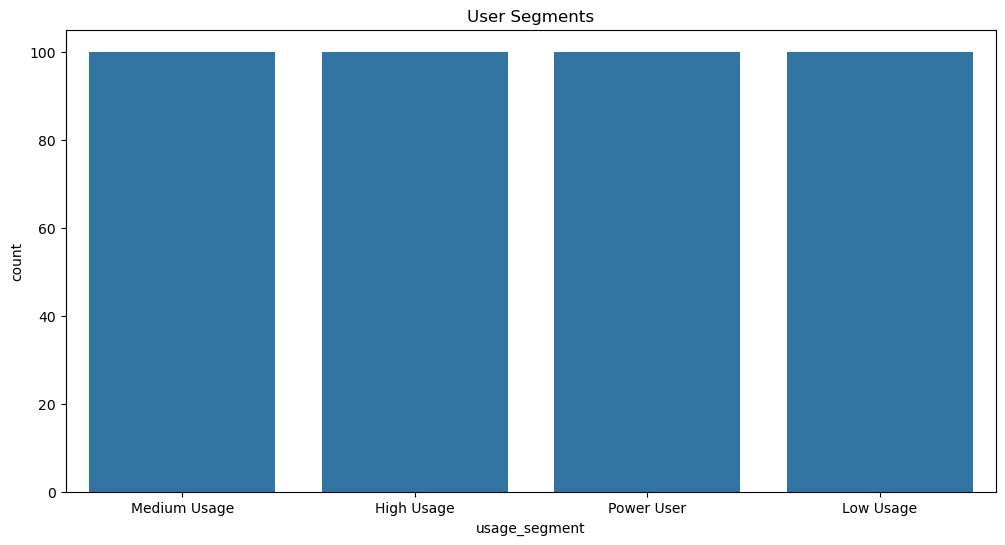

In [13]:
#Segment Visualization
plt.figure(figsize=(12,6))

sns.countplot(
    data=user_profile,
    x="usage_segment"
)

plt.title("User Segments")
plt.show()

In [14]:
#Premium User Analysis
premium_users = user_profile[
    user_profile["spending_segment"]
    == "Premium User"
]

premium_users.head()
len(premium_users)

100

In [15]:
high_risk_users = user_profile[
    user_profile["risk_segment"]
    == "High Risk"
]

high_risk_users.head()

,sender_age_group,sender_state,sender_bank,transaction_count,total_spend,avg_spend,fraud_count,usage_segment,spending_segment,risk_segment,customer_segment
2,18-25,Andhra Pradesh,ICICI,596,689516,1156.906040,3,High Usage,Medium Value,High Risk,High Usage | Medium Value
7,18-25,Andhra Pradesh,Yes Bank,511,671574,1314.234834,3,Medium Usage,Medium Value,High Risk,Medium Usage | Medium Value
8,18-25,Delhi,Axis,588,745491,1267.841837,3,High Usage,High Value,High Risk,High Usage | High Value
9,18-25,Delhi,HDFC,930,1178542,1267.249462,3,Power User,Premium User,High Risk,Power User | Premium User
16,18-25,Gujarat,Axis,525,628407,1196.965714,5,Medium Usage,Medium Value,High Risk,Medium Usage | Medium Value


In [16]:
user_profile.to_csv(
    "../dataset/user_segments.csv",
    index=False
)
premium_users.to_csv(
    "../dataset/premium_users.csv",
    index=False
)
high_risk_users.to_csv(
    "../dataset/high_risk_users.csv",
    index=False
)
